In [1]:
!pip install -q kokoro>=0.9.4 soundfile
!apt-get -qq -y install espeak-ng > /dev/null 2>&1
!pip install -q faster-whisper
!pip install -q jiwer
!pip install -q matplotlib pandas tabulate

print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.4 MB/s eta 0:00:00
✅ All packages installed.


In [2]:
import json

DATASET = {
    "vowels_and_consonants":      {"id": "HIN_01", "text": "एक आम आदमी और औरत इमली के पेड़ के नीचे बैठकर ऊन बुन रहे हैं।"},
    "velars_gutturals":           {"id": "HIN_02", "text": "कमल और काव्या ने खेत से कद्दू उखाड़ा, फिर गरम घी का घड़ा उठाकर घर की ओर भागे।"},
    "retroflexes":                {"id": "HIN_03", "text": "षट्कोण के अंदर रखे ढक्कन और डमरू को देखकर ठग टमाटर टोकरी में डालकर डर गया।"},
    "palatals_and_nasals":        {"id": "HIN_04", "text": "चंचल छतरी लेकर झमाझम बारिश में जंगल की ओर चली गई।"},
    "labials_and_aspirated":      {"id": "HIN_05", "text": "भालू ने भारी पेड़ पर बैठकर मीठा फल खाया और पानी पी लिया।"},
    "loan_words_nukta":           {"id": "HIN_06", "text": "ज़रा फ़िक्र मत करो, क़लम से ख़त लिखकर ग़ज़ल का मज़ा लो।"},
    "complex_conjuncts":          {"id": "HIN_07", "text": "ज्ञानी ऋषि और श्रमिक ने क्षमा, विज्ञान और त्रिशूल का महत्व समझाया।"},
    "dentals_and_visarga":        {"id": "HIN_08", "text": "दुःख मत कर, स्वतः ही नया धन प्राप्त होगा और धर्म की जीत होगी।"},
    "flaps_and_chandrabindu":     {"id": "HIN_09", "text": "गाँव में पाँच ऊँट, एक साँड़, और बड़ी सूँड वाले बूढ़े हाथी खड़े थे।"},
    "approximants_and_sibilants": {"id": "HIN_10", "text": "यश और श्वेता बहुत विश्वास के साथ विद्यालय में योग और व्यायाम सीखने गए।"},
    "english_loan_words":         {"id": "HIN_11", "text": "आजकल के डॉक्टर और इंजीनियर मॉडर्न स्कूल के प्रोजेक्ट पर काम कर रहे हैं।"},
    "heavy_geminates":            {"id": "HIN_12", "text": "बिल्ली ने चम्मच से मक्खन चाटा और छप्पर पर कूदकर गुब्बारा फोड़ दिया।"},
    "ha_placement":               {"id": "HIN_13", "text": "हम कल सुबह शहर के उस बड़े महल की वजह से वहाँ ठहरेंगे।"},
    "vowel_hiatus":               {"id": "HIN_14", "text": "भैया, कौआ उड़ गया, अब आइए और मुझे बताइए कि मैं वहाँ कैसे जाऊँगा?"},
    "sanskrit_tatsama":           {"id": "HIN_15", "text": "इस उज्ज्वल और महत्त्वपूर्ण कार्य के लिए प्राचीन संस्कृति और प्रौद्योगिकी का ज्ञान अनिवार्य है।"},
    "prosody_and_punctuation":    {"id": "HIN_16", "text": "वाह! तुमने तो कमाल कर दिया; लेकिन, क्या तुम्हें सच में लगता है कि यह मुमकिन है?"},
    "perso_arabic_nukta":         {"id": "HIN_17", "text": "ख़ौफ़नाक तूफ़ान के बाज़ू में खड़े फ़क़ीर ने क़र्ज़ माफ़ करने की गुज़ारिश की।"},
    "number_normalization":       {"id": "HIN_18", "text": "सेठ जी ने पचहत्तर प्रतिशत मुनाफ़े के साथ कुल चौवन हज़ार रुपये नकद कमाए।"},
    "consonant_clusters_r":       {"id": "HIN_19", "text": "ट्रेन स्टेशन से प्रस्थान कर चुकी है, कृपया अपने ट्रक को क्रॉसिंग से दूर रखें।"},
    "alliteration_rapid":         {"id": "HIN_20", "text": "चंदू के चाचा ने चाँदी के चम्मच से चटपटी चटनी चखाई और चंपारण चले गए।"},
}

print(f"✅ Loaded {len(DATASET)} evaluation sentences.")
for cat, item in DATASET.items():
    print(f"  [{item['id']}] {cat:<30} → {item['text'][:45]}...")

✅ Loaded 20 evaluation sentences.
  [HIN_01] vowels_and_consonants          → एक आम आदमी और औरत इमली के पेड़ के नीचे बैठकर ...
  [HIN_02] velars_gutturals               → कमल और काव्या ने खेत से कद्दू उखाड़ा, फिर गरम...
  [HIN_03] retroflexes                    → षट्कोण के अंदर रखे ढक्कन और डमरू को देखकर ठग ...
  [HIN_04] palatals_and_nasals            → चंचल छतरी लेकर झमाझम बारिश में जंगल की ओर चली...
  [HIN_05] labials_and_aspirated          → भालू ने भारी पेड़ पर बैठकर मीठा फल खाया और पा...
  [HIN_06] loan_words_nukta               → ज़रा फ़िक्र मत करो, क़लम से ख़त लिखकर ग़ज़ल क...
  [HIN_07] complex_conjuncts              → ज्ञानी ऋषि और श्रमिक ने क्षमा, विज्ञान और त्र...
  [HIN_08] dentals_and_visarga            → दुःख मत कर, स्वतः ही नया धन प्राप्त होगा और ध...
  [HIN_09] flaps_and_chandrabindu         → गाँव में पाँच ऊँट, एक साँड़, और बड़ी सूँड वाल...
  [HIN_10] approximants_and_sibilants     → यश और श्वेता बहुत विश्वास के साथ विद्यालय में...
  [HIN_11] english_loan_words       

In [3]:
from kokoro import KPipeline
import soundfile as sf
import numpy as np
import os, time

# Source: https://github.com/hexgrad/kokoro
# Hindi lang_code = 'h'  (uses espeak-ng for G2P)
# Voice naming: [language][gender]_[name]
#   hf_ = Hindi Female,  hm_ = Hindi Male
# Confirmed voices: hf_alpha, hf_beta (female); hm_omega, hm_psi (male)

HINDI_VOICES = ["hf_alpha", "hf_beta"]
SAMPLE_RATE  = 24000          # Kokoro outputs 24 kHz
OUTPUT_DIR   = "kokoro_hindi_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# lang_code MUST match the voice prefix letter
pipeline = KPipeline(lang_code='h')

print("✅ Kokoro pipeline ready  |  lang='h'  |  voices:", HINDI_VOICES)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


kokoro-v1_0.pth:   0%|          | 0.00/327M [00:00<?, ?B/s]

✅ Kokoro pipeline ready  |  lang='h'  |  voices: ['hf_alpha', 'hf_beta']


In [4]:
from IPython.display import display, Audio

synthesis_results = {}   # { voice: { category: {...} } }

for voice in HINDI_VOICES:
    synthesis_results[voice] = {}
    print(f"\n{'='*60}\n🎤  Voice: {voice}\n{'='*60}")

    for category, item in DATASET.items():
        text    = item["text"]
        sent_id = item["id"]

        t0     = time.time()
        chunks = [audio for _, _, audio in pipeline(text, voice=voice)]
        elapsed = time.time() - t0

        full_audio = np.concatenate(chunks) if len(chunks) > 1 else chunks[0]
        audio_dur  = len(full_audio) / SAMPLE_RATE      # seconds of speech
        rtf        = elapsed / audio_dur                 # Real-Time Factor

        wav_path = os.path.join(OUTPUT_DIR, f"{sent_id}_{voice}.wav")
        sf.write(wav_path, full_audio, SAMPLE_RATE)

        synthesis_results[voice][category] = {
            "audio":      full_audio,
            "audio_dur":  round(audio_dur, 3),
            "synth_time": round(elapsed, 3),
            "rtf":        round(rtf, 4),
            "wav_path":   wav_path,
            "text":       text,
            "id":         sent_id,
        }
        print(f"  [{sent_id}] {category:<30} | dur={audio_dur:.2f}s | RTF={rtf:.3f}")

print("\n✅ Synthesis complete for all voices.")


🎤  Voice: hf_alpha


voices/hf_alpha.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

  [HIN_01] vowels_and_consonants          | dur=6.05s | RTF=0.526
  [HIN_02] velars_gutturals               | dur=7.22s | RTF=0.028
  [HIN_03] retroflexes                    | dur=7.80s | RTF=0.026
  [HIN_04] palatals_and_nasals            | dur=5.62s | RTF=0.029
  [HIN_05] labials_and_aspirated          | dur=5.67s | RTF=0.029
  [HIN_06] loan_words_nukta               | dur=5.10s | RTF=0.030
  [HIN_07] complex_conjuncts              | dur=5.90s | RTF=0.029
  [HIN_08] dentals_and_visarga            | dur=5.55s | RTF=0.036
  [HIN_09] flaps_and_chandrabindu         | dur=5.95s | RTF=0.033
  [HIN_10] approximants_and_sibilants     | dur=6.42s | RTF=0.032
  [HIN_11] english_loan_words             | dur=6.25s | RTF=0.034
  [HIN_12] heavy_geminates                | dur=6.38s | RTF=0.032
  [HIN_13] ha_placement                   | dur=5.72s | RTF=0.033
  [HIN_14] vowel_hiatus                   | dur=5.92s | RTF=0.034
  [HIN_15] sanskrit_tatsama               | dur=7.90s | RTF=0.030
  [HIN_16]

voices/hf_beta.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

  [HIN_01] vowels_and_consonants          | dur=5.20s | RTF=0.084
  [HIN_02] velars_gutturals               | dur=6.60s | RTF=0.028
  [HIN_03] retroflexes                    | dur=7.00s | RTF=0.028
  [HIN_04] palatals_and_nasals            | dur=4.97s | RTF=0.030
  [HIN_05] labials_and_aspirated          | dur=5.12s | RTF=0.030
  [HIN_06] loan_words_nukta               | dur=4.50s | RTF=0.034
  [HIN_07] complex_conjuncts              | dur=5.55s | RTF=0.027
  [HIN_08] dentals_and_visarga            | dur=5.10s | RTF=0.028
  [HIN_09] flaps_and_chandrabindu         | dur=5.47s | RTF=0.030
  [HIN_10] approximants_and_sibilants     | dur=5.75s | RTF=0.028
  [HIN_11] english_loan_words             | dur=5.85s | RTF=0.028
  [HIN_12] heavy_geminates                | dur=5.78s | RTF=0.029
  [HIN_13] ha_placement                   | dur=4.72s | RTF=0.030
  [HIN_14] vowel_hiatus                   | dur=5.38s | RTF=0.029
  [HIN_15] sanskrit_tatsama               | dur=7.20s | RTF=0.028
  [HIN_16]

In [5]:
DEMO_CATEGORY = "alliteration_rapid"   # change to any key in DATASET

for voice in HINDI_VOICES:
    result = synthesis_results[voice][DEMO_CATEGORY]
    print(f"\n🔊 Voice : {voice}")
    print(f"   Text  : {result['text']}")
    display(Audio(data=result["audio"], rate=SAMPLE_RATE, autoplay=False))


🔊 Voice : hf_alpha
   Text  : चंदू के चाचा ने चाँदी के चम्मच से चटपटी चटनी चखाई और चंपारण चले गए।



🔊 Voice : hf_beta
   Text  : चंदू के चाचा ने चाँदी के चम्मच से चटपटी चटनी चखाई और चंपारण चले गए।


In [6]:
from faster_whisper import WhisperModel

# 'medium' is the best accuracy/speed trade-off on a T4
# Use 'large-v3' if you need higher accuracy and don't mind ~2× slower
asr_model = WhisperModel("medium", device="cuda", compute_type="float16")
print("✅ Whisper 'medium' loaded on GPU.")

def transcribe_wav(wav_path: str) -> str:
    """Transcribe a .wav file, forcing Hindi language."""
    segments, _ = asr_model.transcribe(wav_path, language="hi", beam_size=5)
    return "".join(seg.text for seg in segments).strip()

✅ Whisper 'medium' loaded on GPU.


In [7]:
print("Transcribing all files ... (~2–4 min on T4)\n")

for voice in HINDI_VOICES:
    for category in DATASET:
        result = synthesis_results[voice][category]
        result["hypothesis"] = transcribe_wav(result["wav_path"])
        print(f"  [{result['id']}] {voice} | hyp: {result['hypothesis'][:60]}")

print("\n✅ Transcription complete.")

Transcribing all files ... (~2–4 min on T4)

  [HIN_01] hf_alpha | hyp: एक आम आदमी और औरत इम्ली के पेड़ के नीचे बैठकर उन बुन रहे हैं
  [HIN_02] hf_alpha | hyp: कमल और काव्या ने खेथ से कदू उखाडा, फिर गरम गी का घड़ा उठाकर 
  [HIN_03] hf_alpha | hyp: शटकोन के अंदर रखे धखन और दम्रू को देखकर थग तमातर तोक्री में 
  [HIN_04] hf_alpha | hyp: चंचल छत्री लेकर जमाजम भारिश में जंगल की ओर चली गई।
  [HIN_05] hf_alpha | hyp: भालू ने भारी पेर पर बैठ कर मीथा फल खाया और पानी पी लिया।
  [HIN_06] hf_alpha | hyp: जरा फिक्र मत करो, कलम से खत लिख कर गजल का मजा लो.
  [HIN_07] hf_alpha | hyp: ग्यानी रिशी और श्रमिकनिक शमा विग्यान और त्रिशूल का महत्प् सम
  [HIN_08] hf_alpha | hyp: दुख मत कर स्वते ही नेया धन प्राप्त होगा और धर्म की जीत होगी
  [HIN_09] hf_alpha | hyp: गाम में पाँच उंट, एक सानर और बड़ी सुन वाले बूरे हाथी खड़े थे
  [HIN_10] hf_alpha | hyp: यश और स्वेता बहुत विश्वास के साथ विद्याले में योग और व्यायाम
  [HIN_11] hf_alpha | hyp: आजकल के डोक्टर और इंजीनियर मौरन स्कूल के प्रोजेक्ट पर काम कर
  [HIN_12] hf

In [9]:
import jiwer
import unicodedata
import pandas as pd

def normalize_hindi(text: str) -> str:
    """NFC normalise + strip punctuation before scoring."""
    text = unicodedata.normalize("NFC", text)
    for ch in "।,.!?;:'\"()":
        text = text.replace(ch, "")
    return text.strip()

def cer(ref, hyp):
    return jiwer.cer(normalize_hindi(ref), normalize_hindi(hyp))

def wer(ref, hyp):
    return jiwer.wer(normalize_hindi(ref), normalize_hindi(hyp))

rows = []
for voice in HINDI_VOICES:
    for category, result in synthesis_results[voice].items():
        ref = result["text"]
        hyp = result.get("hypothesis", "")
        rows.append({
            "voice":      voice,
            "category":   category,
            "id":         result["id"],
            "reference":  ref,
            "hypothesis": hyp,
            "CER":        round(cer(ref, hyp), 4),
            "WER":        round(wer(ref, hyp), 4),
            "audio_dur":  result["audio_dur"],
            "RTF":        result["rtf"],
        })

df = pd.DataFrame(rows)

# ── Overall summary ────────────────────────────────────────────────────────
summary = df.groupby("voice")[["CER", "WER", "RTF"]].mean().round(4)
print("\n📊 OVERALL MEAN (all 20 sentences)")
print(summary.to_string())

# ── CER pivot by category ──────────────────────────────────────────────────
print("\n📊 CER per Phonological Category")
pivot = df.pivot_table(index="category", columns="voice", values="CER").round(4)
print(pivot.to_string())

MY_MODEL_CHECKPOINT = "/path/to/your/model.pth"
MY_MODEL_LABEL      = "my_finetuned_model"


📊 OVERALL MEAN (all 20 sentences)
             CER     WER     RTF
voice                           
hf_alpha  0.1264  0.3562  0.0555
hf_beta   0.1316  0.3625  0.0313

📊 CER per Phonological Category
voice                       hf_alpha  hf_beta
category                                     
alliteration_rapid            0.0606   0.1667
approximants_and_sibilants    0.0435   0.0290
complex_conjuncts             0.2500   0.1719
consonant_clusters_r          0.0933   0.0800
dentals_and_visarga           0.0508   0.1186
english_loan_words            0.0571   0.0571
flaps_and_chandrabindu        0.1905   0.2381
ha_placement                  0.0577   0.0769
heavy_geminates               0.1212   0.1515
labials_and_aspirated         0.0727   0.0182
loan_words_nukta              0.1509   0.1509
number_normalization          0.4143   0.4000
palatals_and_nasals           0.0833   0.1667
perso_arabic_nukta            0.1600   0.1467
prosody_and_punctuation       0.0933   0.0667
retroflexes       

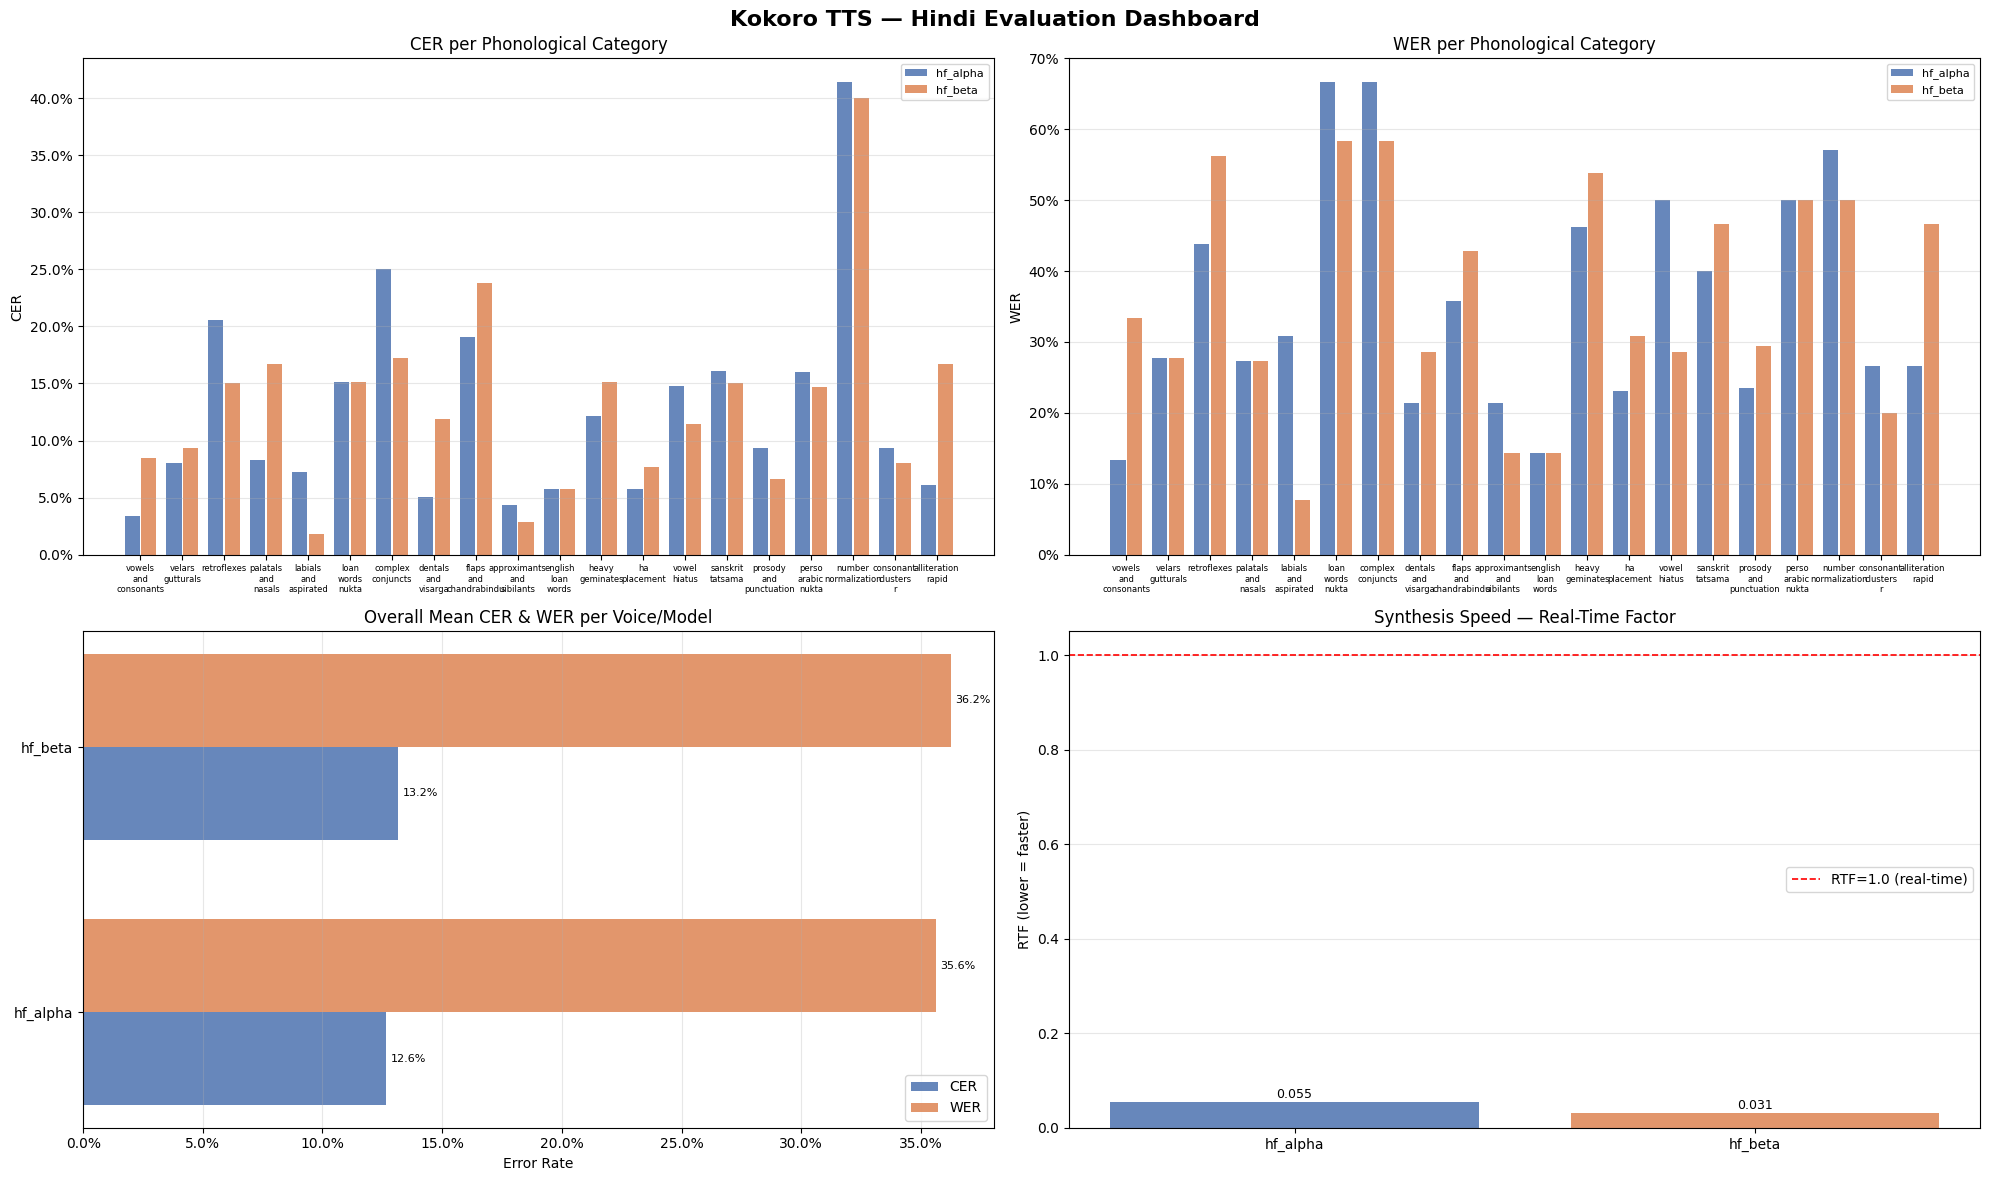

✅ Dashboard saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

voices_present = df["voice"].unique().tolist()
palette   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
color_map = {v: palette[i % len(palette)] for i, v in enumerate(voices_present)}
cats      = df["category"].unique()
x         = np.arange(len(cats))
width     = 0.8 / len(voices_present)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle("Kokoro TTS — Hindi Evaluation Dashboard", fontsize=16, fontweight="bold")

# ── 1. CER per category ────────────────────────────────────────────────────
ax = axes[0, 0]
for i, v in enumerate(voices_present):
    vals = [df[(df.voice==v) & (df.category==c)]["CER"].values[0]
            if len(df[(df.voice==v) & (df.category==c)]) else 0 for c in cats]
    ax.bar(x + i*width - (len(voices_present)-1)*width/2,
           vals, width*0.9, label=v, color=color_map[v], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in cats], fontsize=6)
ax.set_ylabel("CER"); ax.set_title("CER per Phonological Category")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# ── 2. WER per category ────────────────────────────────────────────────────
ax = axes[0, 1]
for i, v in enumerate(voices_present):
    vals = [df[(df.voice==v) & (df.category==c)]["WER"].values[0]
            if len(df[(df.voice==v) & (df.category==c)]) else 0 for c in cats]
    ax.bar(x + i*width - (len(voices_present)-1)*width/2,
           vals, width*0.9, label=v, color=color_map[v], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in cats], fontsize=6)
ax.set_ylabel("WER"); ax.set_title("WER per Phonological Category")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# ── 3. Overall CER + WER comparison ───────────────────────────────────────
ax = axes[1, 0]
overall = df.groupby("voice")[["CER","WER"]].mean()
y, h = np.arange(len(overall)), 0.35
ax.barh(y-h/2, overall["CER"].values, h, label="CER", color="#4C72B0", alpha=0.85)
ax.barh(y+h/2, overall["WER"].values, h, label="WER", color="#DD8452", alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(overall.index.tolist())
ax.set_xlabel("Error Rate"); ax.set_title("Overall Mean CER & WER per Voice/Model")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(axis="x", alpha=0.3)
for i,(c,w) in enumerate(zip(overall["CER"].values, overall["WER"].values)):
    ax.text(c+0.002, i-h/2, f"{c:.1%}", va="center", fontsize=8)
    ax.text(w+0.002, i+h/2, f"{w:.1%}", va="center", fontsize=8)

# ── 4. RTF ─────────────────────────────────────────────────────────────────
ax = axes[1, 1]
rtf_s = df.groupby("voice")["RTF"].mean()
bars  = ax.bar(rtf_s.index, rtf_s.values,
               color=[color_map[v] for v in rtf_s.index], alpha=0.85)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="RTF=1.0 (real-time)")
ax.set_ylabel("RTF (lower = faster)"); ax.set_title("Synthesis Speed — Real-Time Factor")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, rtf_s.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("kokoro_hindi_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved.")

🔴 Hardest categories (highest CER):
   number_normalization                40.7%
   flaps_and_chandrabindu              21.4%
   complex_conjuncts                   21.1%
   retroflexes                         17.8%
   sanskrit_tatsama                    15.6%

🟢 Easiest categories (lowest CER):
   ha_placement                        6.7%
   vowels_and_consonants               5.9%
   english_loan_words                  5.7%
   labials_and_aspirated               4.5%
   approximants_and_sibilants          3.6%


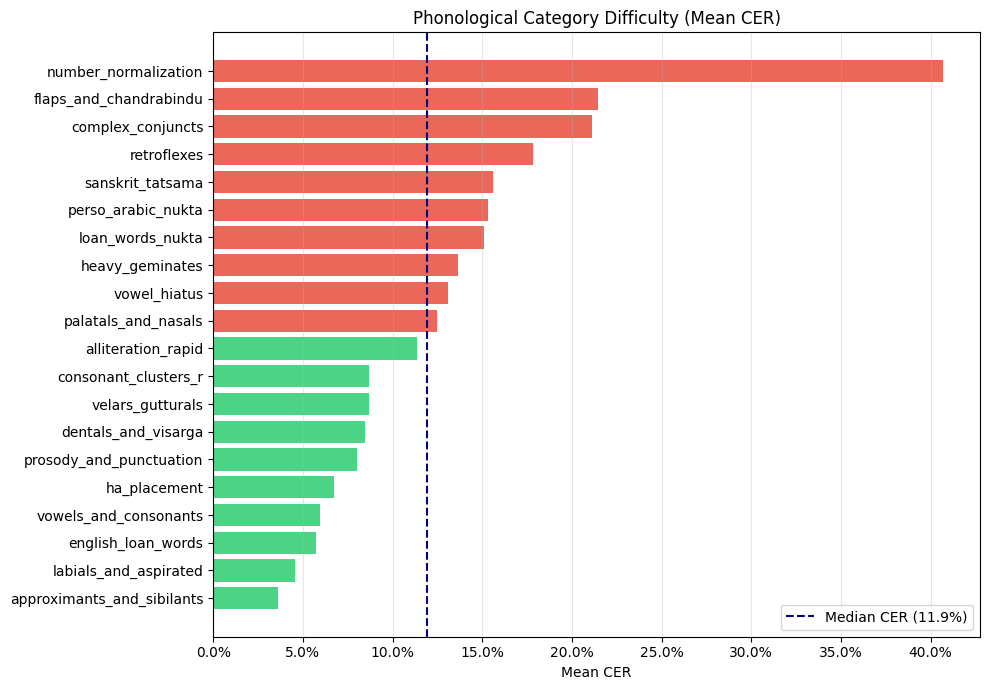

In [13]:
cat_cer = df.groupby("category")["CER"].mean().sort_values(ascending=False)

print("🔴 Hardest categories (highest CER):")
for cat, val in cat_cer.head(5).items():
    print(f"   {cat:<35} {val:.1%}")

print("\n🟢 Easiest categories (lowest CER):")
for cat, val in cat_cer.tail(5).items():
    print(f"   {cat:<35} {val:.1%}")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if v > cat_cer.median() else "#2ecc71" for v in cat_cer.values]
ax.barh(cat_cer.index[::-1], cat_cer.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(cat_cer.median(), color="navy", linestyle="--",
           label=f"Median CER ({cat_cer.median():.1%})")
ax.set_xlabel("Mean CER"); ax.set_title("Phonological Category Difficulty (Mean CER)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("kokoro_category_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from tabulate import tabulate

print(tabulate(
    df[["voice","id","category","CER","WER","RTF","audio_dur"]].sort_values(["voice","id"]),
    headers="keys", tablefmt="github", floatfmt=".4f", showindex=False
))

summary = df.groupby("voice").agg(
    mean_CER=("CER","mean"), mean_WER=("WER","mean"),
    best_CER=("CER","min"),  worst_CER=("CER","max"),
    mean_RTF=("RTF","mean"), total_audio_sec=("audio_dur","sum"),
).round(4)
print("\n", summary.to_string())

df.to_csv("kokoro_hindi_eval_results.csv", index=False)
print("\n✅ Saved to kokoro_hindi_eval_results.csv")

| voice    | id     | category                   |    CER |    WER |    RTF |   audio_dur |
|----------|--------|----------------------------|--------|--------|--------|-------------|
| hf_alpha | HIN_01 | vowels_and_consonants      | 0.0339 | 0.1333 | 0.5264 |      6.0500 |
| hf_alpha | HIN_02 | velars_gutturals           | 0.0800 | 0.2778 | 0.0283 |      7.2250 |
| hf_alpha | HIN_03 | retroflexes                | 0.2055 | 0.4375 | 0.0262 |      7.8000 |
| hf_alpha | HIN_04 | palatals_and_nasals        | 0.0833 | 0.2727 | 0.0286 |      5.6250 |
| hf_alpha | HIN_05 | labials_and_aspirated      | 0.0727 | 0.3077 | 0.0290 |      5.6750 |
| hf_alpha | HIN_06 | loan_words_nukta           | 0.1509 | 0.6667 | 0.0304 |      5.1000 |
| hf_alpha | HIN_07 | complex_conjuncts          | 0.2500 | 0.6667 | 0.0293 |      5.9000 |
| hf_alpha | HIN_08 | dentals_and_visarga        | 0.0508 | 0.2143 | 0.0356 |      5.5500 |
| hf_alpha | HIN_09 | flaps_and_chandrabindu     | 0.1905 | 0.3571 | 0.0333 |   

In [15]:
from google.colab import files

files.download("kokoro_hindi_eval_results.csv")
files.download("kokoro_hindi_dashboard.png")
files.download("kokoro_category_difficulty.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import shutil
from google.colab import files

# Zips the entire kokoro_hindi_outputs folder into one file
shutil.make_archive("kokoro_hindi_audio", "zip", OUTPUT_DIR)
files.download("kokoro_hindi_audio.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>